# Manual validation and analysis of extracted argument graphs

This notebook supports two uses:

1. annotate a mixed pilot sample (for example, 20 graphs) to validate quality;
2. inspect a full extraction for one model run.

The runner stores mixed samples and full runs in separate folders. This notebook mirrors that structure, so graph images, annotation files, and summaries never collide across runs.

Each successful record may contain:

- `raw_graph`: the exact combined output of the three Gemini calls;
- `graph`: the analysis graph after **lossless normalization only**;
- `repairs`: an audit trail describing every normalization.

The repairs may trim outer whitespace, canonicalize identifiers, remove exact duplicates, and copy inference-group membership from the fixed edges. They never add, delete, merge, split, reconnect, or reinterpret argumentative content. When a repair is applied, compare the raw and normalized graphs and flag `incorrect_repair` if the normalization changed meaning.

Evaluate whether each graph faithfully reconstructs the model-generated justification. Do not judge whether the underlying vote or game reasoning is factually correct.


In [1]:
from pathlib import Path
from typing import Optional

REPO_NAME = "masters_thesis_sdg"

def find_repo_root(start: Optional[Path] = None, repo_name: str = REPO_NAME) -> Path:
    """Walk upward until the repository root folder is found."""
    current = (start or Path.cwd()).resolve()

    while True:
        if current.name == repo_name:
            return current

        if current.parent == current:
            raise FileNotFoundError(
                f"Could not find repo root {repo_name!r} starting from {start or Path.cwd()}"
            )

        current = current.parent

In [4]:
import re
from pathlib import Path

root = find_repo_root()

# -----------------------------
# Source experiment
# -----------------------------
SOURCE_MODEL = "unsloth_gemma-4-31B-it-unsloth-bnb-4bit"
PROMPT_VERSION = "prompt_v4"

# Choose:
#   "sample" -> mixed pilot created with --sample-size
#   "run"    -> one complete run created with --run-label
MODE = "sample"

# Used when MODE == "sample".
# This must match the folder created by the runner.
SAMPLE_SCOPE = "mixed_n50_seed42"

# Used when MODE == "run".
RUN_LABEL = "run_1"

ANALYSIS_ROOT = (
    root
    / "analysis"
    / SOURCE_MODEL
    / "base"
    / "voting"
    / PROMPT_VERSION
    / "justification_analysis"
    / "three_call_deepseek"
)

if MODE == "sample":
    GRAPH_PATH = ANALYSIS_ROOT / "samples" / SAMPLE_SCOPE / "graphs.jsonl"
    SCOPE_NAME = SAMPLE_SCOPE
elif MODE == "run":
    SCOPE_NAME = re.sub(r"[^A-Za-z0-9._-]+", "_", RUN_LABEL).strip("._-")
    GRAPH_PATH = ANALYSIS_ROOT / "runs" / SCOPE_NAME / "graphs.jsonl"
else:
    raise ValueError("MODE must be 'sample' or 'run'.")

# -----------------------------
# Scope-specific outputs
# -----------------------------
OUTPUT_DIR = ANALYSIS_ROOT / "manual_review" / SCOPE_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_DIR = OUTPUT_DIR / "graph_images"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

RAW_IMAGE_DIR = OUTPUT_DIR / "raw_graph_images"
RAW_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_CSV_PATH = OUTPUT_DIR / "sampled_graphs_for_validation.csv"
REVIEW_CSV_PATH = OUTPUT_DIR / "manual_graph_validation.csv"
HTML_PATH = OUTPUT_DIR / "manual_graph_review_pack.html"

# -----------------------------
# Review and rendering
# -----------------------------
# Mixed pilot: annotate every extracted item.
# Full run: draw a representative + stress sample for manual review.
REVIEW_ALL_RECORDS = MODE == "sample"

N_REPRESENTATIVE = 40
N_STRESS = 10
RANDOM_STATE = 42

# For a full run, 191 SVGs are manageable and useful for later inspection.
# Set False to render only the manual-review sample.
RENDER_ALL_GRAPHS = MODE == "run"

print("Graph file :", GRAPH_PATH)
print("Review dir :", OUTPUT_DIR)


Graph file : C:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\unsloth_gemma-4-31B-it-unsloth-bnb-4bit\base\voting\prompt_v4\justification_analysis\three_call_deepseek\samples\mixed_n50_seed42\graphs.jsonl
Review dir : C:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\unsloth_gemma-4-31B-it-unsloth-bnb-4bit\base\voting\prompt_v4\justification_analysis\three_call_deepseek\manual_review\mixed_n50_seed42


In [5]:
import json
import html
import textwrap
from collections import Counter, OrderedDict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from IPython.display import display, Markdown, HTML


In [6]:
def load_jsonl(path):
    """
    Load either:
    - a JSONL file: one JSON object per line
    - a JSON file containing a list of objects

    Returns a list of records.
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    text = path.read_text(encoding="utf-8").strip()

    if not text:
        return []


    # JSONL
    records = []
    with path.open("r", encoding="utf-8") as f:
        for line_number, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue

            try:
                obj = json.loads(line)
            except json.JSONDecodeError as e:
                raise ValueError(f"Invalid JSON on line {line_number}: {e}")

            records.append(obj)

    return records


records = load_jsonl(GRAPH_PATH)

print(f"Loaded {len(records)} graph records.")

Loaded 54 graph records.


In [7]:
# Automatic structural validation.
# This checks schema consistency only, not semantic graph quality.

ALLOWED_ARGUMENT_ROLES = {"Premise", "Conclusion"}
ALLOWED_REASONING_TYPES = {
    "Game-Mechanical",
    "Claim-Consistency",
    "Behavioral-Credibility",
    "Social-Consensus",
    "Individual-Testimony",
    "Epistemic-Uncertainty",
    "Generic-Heuristic",
}
ALLOWED_EDGE_RELATIONS = {"supports", "attacks"}


def detect_cycle(nodes, edges):
    node_ids = {n.get("id") for n in nodes if isinstance(n, dict)}
    adjacency = {node_id: [] for node_id in node_ids}

    for edge in edges:
        if not isinstance(edge, dict):
            continue
        source = edge.get("source")
        target = edge.get("target")
        if source in adjacency and target in node_ids:
            adjacency[source].append(target)

    WHITE, GRAY, BLACK = 0, 1, 2
    color = {node_id: WHITE for node_id in node_ids}
    cycle_path = []

    def dfs(node_id, path):
        color[node_id] = GRAY
        path.append(node_id)

        for neighbor in adjacency.get(node_id, []):
            if color[neighbor] == GRAY:
                start = path.index(neighbor)
                cycle_path.extend(path[start:] + [neighbor])
                return True
            if color[neighbor] == WHITE and dfs(neighbor, path):
                return True

        path.pop()
        color[node_id] = BLACK
        return False

    for node_id in node_ids:
        if color[node_id] == WHITE and dfs(node_id, []):
            break

    return cycle_path


def expected_inference_groups(edges):
    groups = OrderedDict()
    issues = []

    for edge in edges:
        if not isinstance(edge, dict):
            continue

        group_id = edge.get("inference_group")
        source = edge.get("source")
        target = edge.get("target")
        relation = edge.get("relation")

        if not group_id:
            continue

        if group_id not in groups:
            groups[group_id] = {
                "sources": [source],
                "target": target,
                "relation": relation,
            }
            continue

        group = groups[group_id]

        if group["target"] != target:
            issues.append(f"inference_group_mixes_targets:{group_id}")

        if group["relation"] != relation:
            issues.append(f"inference_group_mixes_relations:{group_id}")

        if source not in group["sources"]:
            group["sources"].append(source)

    return groups, issues


def validate_graph_schema(obj, graph_key="graph"):
    issues = []

    graph = obj.get(graph_key, obj.get("graph", {}) if graph_key == "raw_graph" else {})
    nodes = graph.get("nodes", [])
    edges = graph.get("edges", [])
    inference_groups = graph.get("inference_groups", [])

    if not isinstance(nodes, list):
        return ["nodes_not_list"]
    if not isinstance(edges, list):
        return ["edges_not_list"]
    if not isinstance(inference_groups, list):
        return ["inference_groups_not_list"]

    node_ids = []
    for node in nodes:
        if not isinstance(node, dict):
            issues.append("node_not_object")
            continue

        node_id = node.get("id")
        node_ids.append(node_id)

        if node.get("argument_role") not in ALLOWED_ARGUMENT_ROLES:
            issues.append(f"invalid_argument_role:{node.get('argument_role')}")

        if not str(node.get("text", "")).strip():
            issues.append(f"empty_node_text:{node_id}")

    if len(node_ids) != len(set(node_ids)):
        issues.append("duplicate_node_ids")

    expected_ids = [f"n{i}" for i in range(1, len(nodes) + 1)]
    if node_ids != expected_ids:
        issues.append("non_sequential_node_ids")

    node_id_set = set(node_ids)
    seen_pairs = set()
    seen_edges = set()

    for edge in edges:
        if not isinstance(edge, dict):
            issues.append("edge_not_object")
            continue

        source = edge.get("source")
        target = edge.get("target")
        relation = edge.get("relation")
        group_id = edge.get("inference_group")

        if source not in node_id_set:
            issues.append(f"edge_source_missing:{source}")
        if target not in node_id_set:
            issues.append(f"edge_target_missing:{target}")
        if source == target:
            issues.append(f"self_edge:{source}")
        if relation not in ALLOWED_EDGE_RELATIONS:
            issues.append(f"invalid_edge_relation:{relation}")
        if not str(group_id or "").strip():
            issues.append(f"missing_inference_group:{source}->{target}")

        pair = (source, target)
        if pair in seen_pairs:
            issues.append(f"duplicate_source_target_pair:{source}->{target}")
        seen_pairs.add(pair)

        edge_key = (source, target, relation, group_id)
        if edge_key in seen_edges:
            issues.append(f"duplicate_edge:{edge_key}")
        seen_edges.add(edge_key)

    conclusion_ids = {
        node.get("id")
        for node in nodes
        if isinstance(node, dict)
        and node.get("argument_role") == "Conclusion"
    }

    if len(conclusion_ids) > 1:
        issues.append("multiple_conclusions")

    for edge in edges:
        if isinstance(edge, dict) and edge.get("source") in conclusion_ids:
            issues.append("conclusion_has_outgoing_edge")

    if detect_cycle(nodes, edges):
        issues.append("graph_has_cycle")

    expected_groups, group_issues = expected_inference_groups(edges)
    issues.extend(group_issues)

    returned_groups = {}
    for group in inference_groups:
        if not isinstance(group, dict):
            issues.append("inference_group_not_object")
            continue

        group_id = group.get("inference_group")

        if group_id in returned_groups:
            issues.append(f"duplicate_inference_group_classification:{group_id}")

        returned_groups[group_id] = group

        if group.get("reasoning_type") not in ALLOWED_REASONING_TYPES:
            issues.append(
                f"invalid_reasoning_type:{group.get('reasoning_type')}"
            )

    for group_id, expected in expected_groups.items():
        returned = returned_groups.get(group_id)

        if returned is None:
            issues.append(f"missing_inference_group_classification:{group_id}")
            continue

        if returned.get("target") != expected["target"]:
            issues.append(f"wrong_group_target:{group_id}")

        if returned.get("relation") != expected["relation"]:
            issues.append(f"wrong_group_relation:{group_id}")

        if returned.get("sources") != expected["sources"]:
            issues.append(f"wrong_group_sources:{group_id}")

    for group_id in returned_groups:
        if group_id not in expected_groups:
            issues.append(f"unknown_inference_group_classification:{group_id}")

    if not edges and inference_groups:
        issues.append("groups_present_without_edges")

    return sorted(set(issues))


In [11]:
# Flatten records into one row per graph for analysis and sampling.

def graph_record_to_row(obj, record_id):
    metadata = obj.get("metadata", {})
    input_data = obj.get("input", {})
    graph = obj.get("graph", {})
    raw_graph = obj.get("raw_graph", graph)
    repairs = obj.get("repairs", [])

    nodes = graph.get("nodes", [])
    edges = graph.get("edges", [])
    inference_groups = graph.get("inference_groups", [])

    raw_nodes = raw_graph.get("nodes", []) if isinstance(raw_graph, dict) else []
    raw_edges = raw_graph.get("edges", []) if isinstance(raw_graph, dict) else []
    raw_groups = raw_graph.get("inference_groups", []) if isinstance(raw_graph, dict) else []

    node_roles = [
        node.get("argument_role")
        for node in nodes
        if isinstance(node, dict)
    ]
    edge_relations = [
        edge.get("relation")
        for edge in edges
        if isinstance(edge, dict)
    ]
    reasoning_types = [
        group.get("reasoning_type")
        for group in inference_groups
        if isinstance(group, dict)
    ]

    schema_issues = validate_graph_schema(obj, graph_key="graph")
    raw_schema_issues = validate_graph_schema(obj, graph_key="raw_graph")

    group_sizes = [
        len(group.get("sources", []))
        for group in inference_groups
        if isinstance(group, dict)
    ]

    groups_per_target = {}
    for group in inference_groups:
        if not isinstance(group, dict):
            continue
        groups_per_target.setdefault(group.get("target"), set()).add(
            group.get("inference_group")
        )

    repair_types = [
        repair.get("type")
        for repair in repairs
        if isinstance(repair, dict) and repair.get("type")
    ]

    return {
        "record_id": record_id,
        "scope_name": SCOPE_NAME,

        "row_index": metadata.get("row_index"),
        "game_id": metadata.get("game_id"),
        "run_label": metadata.get("run_label"),
        "chosen_vote": metadata.get("chosen_vote"),
        "vote_correct": metadata.get("is_correct"),

        "prompt_version": metadata.get("prompt_version"),
        "model_name": metadata.get("model_name"),
        "extractor_model": metadata.get("extractor_model"),
        "schema_version": metadata.get("schema_version"),
        "repair_policy_version": metadata.get("repair_policy_version"),
        "generation_config": metadata.get("generation_config", {}),
        "raw_validation_flags": metadata.get("raw_validation_flags", []),
        "validation_flags": metadata.get("validation_flags", []),

        "justification": input_data.get("justification", ""),

        "n_nodes": len(nodes),
        "n_edges": len(edges),
        "n_inference_groups": len(inference_groups),
        "raw_n_nodes": len(raw_nodes),
        "raw_n_edges": len(raw_edges),
        "raw_n_inference_groups": len(raw_groups),
        "n_conclusions": sum(role == "Conclusion" for role in node_roles),
        "has_attack": "attacks" in edge_relations,
        "n_linked_inference_groups": sum(size > 1 for size in group_sizes),
        "n_targets_with_multiple_inferences": sum(
            len(group_ids) > 1
            for group_ids in groups_per_target.values()
        ),
        "n_support_inference_groups": sum(
            group.get("relation") == "supports"
            for group in inference_groups
            if isinstance(group, dict)
        ),
        "n_attack_inference_groups": sum(
            group.get("relation") == "attacks"
            for group in inference_groups
            if isinstance(group, dict)
        ),

        "node_roles": sorted(
            set(role for role in node_roles if role is not None)
        ),
        "reasoning_types": sorted(
            set(rt for rt in reasoning_types if rt is not None)
        ),
        "edge_relations": sorted(
            set(rel for rel in edge_relations if rel is not None)
        ),

        "repairs": repairs,
        "n_repairs": len(repairs),
        "repair_types": repair_types,
        "raw_graph_differs": raw_graph != graph,

        "raw_schema_issues": raw_schema_issues,
        "n_raw_schema_issues": len(raw_schema_issues),
        "schema_issues": schema_issues,
        "n_schema_issues": len(schema_issues),

        "raw_obj": obj,
    }


successful_records = [
    obj for obj in records
    if isinstance(obj.get("graph"), dict)
]

df = pd.DataFrame([
    graph_record_to_row(obj, record_id=i)
    for i, obj in enumerate(successful_records)
])

print(
    f"Loaded {len(successful_records)} successful graph(s) "
    f"from {len(records)} record(s)."
)
df.head()


Loaded 50 successful graph(s) from 54 record(s).


,record_id,scope_name,row_index,game_id,run_label,chosen_vote,vote_correct,prompt_version,model_name,extractor_model,...,edge_relations,repairs,n_repairs,repair_types,raw_graph_differs,raw_schema_issues,n_raw_schema_issues,schema_issues,n_schema_issues,raw_obj
0,0,mixed_n50_seed42,36,Ego4D / 64076f60-f3fc-4ee6-93e1-3489d8ec7b12 /...,run_1,Brent,True,prompt_v4,unsloth_gemma-4-31B-it-unsloth-bnb-4bit,deepseek-v4-pro,...,[supports],[],0,[],False,[],0,[],0,"{'metadata': {'row_index': 36, 'game_id': 'Ego..."
1,1,mixed_n50_seed42,696,Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF#43##Octo...,greedy_t0,Mitchell,True,prompt_v4,unsloth_gemma-4-31B-it-unsloth-bnb-4bit,deepseek-v4-pro,...,[supports],[],0,[],False,[],0,[],0,"{'metadata': {'row_index': 696, 'game_id': 'Yo..."
2,2,mixed_n50_seed42,207,Ego4D / 2ba4023c-a8bf-43ad-ad5a-80ba222ce990 /...,run_2,Erin,False,prompt_v4,unsloth_gemma-4-31B-it-unsloth-bnb-4bit,deepseek-v4-pro,...,[supports],[],0,[],False,[],0,[],0,"{'metadata': {'row_index': 207, 'game_id': 'Eg..."
3,3,mixed_n50_seed42,137,Youtube / One#Night#Ultimate#Werewolf#531#Clas...,run_1,Brett,False,prompt_v4,unsloth_gemma-4-31B-it-unsloth-bnb-4bit,deepseek-v4-pro,...,[supports],[],0,[],False,[],0,[],0,"{'metadata': {'row_index': 137, 'game_id': 'Yo..."
4,4,mixed_n50_seed42,638,Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF##Retro#2...,greedy_t0,No Werewolf,False,prompt_v4,unsloth_gemma-4-31B-it-unsloth-bnb-4bit,deepseek-v4-pro,...,[supports],[],0,[],False,[],0,[],0,"{'metadata': {'row_index': 638, 'game_id': 'Yo..."


In [12]:
print("Number of graphs:", len(df))
print()

print("Runs represented:")
display(df["run_label"].value_counts(dropna=False).to_frame("count"))
print()

print("Vote correctness:")
display(df["vote_correct"].value_counts(dropna=False).to_frame("count"))
print()

print("Graph size after lossless normalization:")
display(
    df[["n_nodes", "n_edges", "n_inference_groups"]]
    .describe()
    .T
)
print()

print("Graphs with attacks:", int(df["has_attack"].sum()))
print(
    "Graphs with at least one linked inference:",
    int((df["n_linked_inference_groups"] > 0).sum()),
)
print(
    "Graphs receiving at least one lossless repair:",
    int((df["n_repairs"] > 0).sum()),
)
print(
    "Graphs where raw and normalized representations differ:",
    int(df["raw_graph_differs"].sum()),
)
print(
    "Raw graphs with structural issues:",
    int((df["n_raw_schema_issues"] > 0).sum()),
)
print(
    "Normalized graphs with structural issues:",
    int((df["n_schema_issues"] > 0).sum()),
)

if df["n_repairs"].sum() > 0:
    print()
    print("Repair types:")
    display(count_list_column(df["repair_types"]))


Number of graphs: 50

Runs represented:


,count
run_label,
run_1,13
greedy_t0,13
run_2,12
run_3,12



Vote correctness:


,count
vote_correct,
False,29
True,21



Graph size after lossless normalization:


,count,mean,std,min,25%,50%,75%,max
n_nodes,50.0,5.42,1.326188,3.0,5.0,5.0,6.0,9.0
n_edges,50.0,4.10,1.460361,1.0,3.0,4.0,5.0,8.0
n_inference_groups,50.0,3.02,1.169162,1.0,2.0,3.0,4.0,6.0



Graphs with attacks: 11
Graphs with at least one linked inference: 35
Graphs receiving at least one lossless repair: 0
Graphs where raw and normalized representations differ: 0
Raw graphs with structural issues: 0
Normalized graphs with structural issues: 0


In [14]:
# Inspect normalization and remaining schema problems before annotation.
problem_rows = df[
    (df["n_repairs"] > 0)
    | (df["n_raw_schema_issues"] > 0)
    | (df["n_schema_issues"] > 0)
]

display(
    problem_rows[
        [
            "record_id",
            "row_index",
            "game_id",
            "run_label",
            "repair_types",
            "raw_schema_issues",
            "schema_issues",
        ]
    ]
)


,record_id,row_index,game_id,run_label,repair_types,raw_schema_issues,schema_issues


In [15]:
def count_list_column(series):
    counter = Counter()

    for values in series:
        if isinstance(values, list):
            counter.update(values)

    if not counter:
        return pd.DataFrame(columns=["label", "count"])

    return (
        pd.DataFrame(counter.items(), columns=["label", "count"])
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )


print("Argument roles:")
display(count_list_column(df["node_roles"]))

print("Reasoning types:")
display(count_list_column(df["reasoning_types"]))

print("Edge relations:")
display(count_list_column(df["edge_relations"]))


def flatten_inference_groups(records):
    rows = []

    for record_id, obj in enumerate(records):
        metadata = obj.get("metadata", {})
        graph = obj.get("graph", {})

        for group in graph.get("inference_groups", []):
            if not isinstance(group, dict):
                continue

            rows.append({
                "record_id": record_id,
                "game_id": metadata.get("game_id"),
                "run_label": metadata.get("run_label"),
                "vote_correct": metadata.get("is_correct"),
                "inference_group": group.get("inference_group"),
                "sources": group.get("sources", []),
                "target": group.get("target"),
                "relation": group.get("relation"),
                "reasoning_type": group.get("reasoning_type"),
            })

    return pd.DataFrame(rows)


inference_df = flatten_inference_groups(successful_records)

REASONING_FAMILY = {
    "Game-Mechanical": "Mechanical deduction",
    "Claim-Consistency": "Non-mechanical comparison",
    "Behavioral-Credibility": "Persuasion-sensitive",
    "Social-Consensus": "Persuasion-sensitive",
    "Individual-Testimony": "Persuasion-sensitive",
    "Epistemic-Uncertainty": "Epistemic uncertainty",
    "Generic-Heuristic": "Generic / unspecified",
}

if len(inference_df) > 0:
    inference_df["reasoning_family"] = inference_df["reasoning_type"].map(
        REASONING_FAMILY
    )

    reasoning_summary = (
        inference_df["reasoning_type"]
        .value_counts()
        .rename_axis("reasoning_type")
        .reset_index(name="count")
    )
    reasoning_summary["percent"] = (
        100 * reasoning_summary["count"] / reasoning_summary["count"].sum()
    ).round(2)

    family_summary = (
        inference_df["reasoning_family"]
        .value_counts()
        .rename_axis("reasoning_family")
        .reset_index(name="count")
    )
    family_summary["percent"] = (
        100 * family_summary["count"] / family_summary["count"].sum()
    ).round(2)

    print("Inference-level reasoning types:")
    display(reasoning_summary)

    print("Research-question families:")
    display(family_summary)

    if inference_df["run_label"].nunique(dropna=False) > 1:
        print("Reasoning types by run:")
        display(
            pd.crosstab(
                inference_df["run_label"],
                inference_df["reasoning_type"],
                normalize="index",
            ).mul(100).round(2)
        )
else:
    print("No inference groups to summarize.")


Argument roles:


,label,count
0,Conclusion,50
1,Premise,50


Reasoning types:


,label,count
0,Behavioral-Credibility,36
1,Game-Mechanical,30
2,Claim-Consistency,16
3,Individual-Testimony,10
4,Generic-Heuristic,9
5,Social-Consensus,4
6,Epistemic-Uncertainty,3


Edge relations:


...

,reasoning_type,count,percent
0,Behavioral-Credibility,55,36.42
1,Game-Mechanical,46,30.46
2,Claim-Consistency,20,13.25
3,Individual-Testimony,12,7.95
4,Generic-Heuristic,10,6.62
5,Social-Consensus,4,2.65
6,Epistemic-Uncertainty,4,2.65


Research-question families:


,reasoning_family,count,percent
0,Persuasion-sensitive,71,47.02
1,Mechanical deduction,46,30.46
2,Non-mechanical comparison,20,13.25
3,Generic / unspecified,10,6.62
4,Epistemic uncertainty,4,2.65


Reasoning types by run:


reasoning_type,Behavioral-Credibility,Claim-Consistency,Epistemic-Uncertainty,Game-Mechanical,Generic-Heuristic,Individual-Testimony,Social-Consensus
run_label,,,,,,,
greedy_t0,30.77,12.82,0.00,41.03,7.69,7.69,0.00
run_1,35.71,14.29,4.76,26.19,4.76,11.90,2.38
run_2,51.43,8.57,2.86,17.14,5.71,5.71,8.57
run_3,28.57,17.14,2.86,37.14,8.57,5.71,0.00


In [16]:
def stratified_random_sample(df, n, stratify_col, random_state=42):
    if n <= 0:
        return df.iloc[0:0].copy()

    groups = list(df.groupby(stratify_col, dropna=False))
    if not groups:
        return df.iloc[0:0].copy()

    base_n = n // len(groups)
    remainder = n % len(groups)
    sampled_parts = []

    for group_idx, (_, group) in enumerate(groups):
        target_n = base_n + (1 if group_idx < remainder else 0)
        target_n = min(target_n, len(group))

        if target_n > 0:
            sampled_parts.append(
                group.sample(
                    n=target_n,
                    random_state=random_state + group_idx,
                )
            )

    sampled = (
        pd.concat(sampled_parts)
        if sampled_parts
        else df.iloc[0:0].copy()
    )

    remaining_n = n - len(sampled)
    if remaining_n > 0:
        pool = df.drop(index=sampled.index)
        if len(pool) > 0:
            sampled = pd.concat([
                sampled,
                pool.sample(
                    n=min(remaining_n, len(pool)),
                    random_state=random_state,
                ),
            ])

    return sampled


def make_validation_sample(
    df,
    n_representative=40,
    n_stress=10,
    random_state=42,
):
    representative = stratified_random_sample(
        df,
        n=n_representative,
        stratify_col="vote_correct",
        random_state=random_state,
    ).copy()
    representative["sample_type"] = "representative"

    remaining = df.drop(index=representative.index).copy()

    if len(remaining) > 0:
        remaining["stress_score"] = (
            remaining["n_nodes"]
            + remaining["n_edges"]
            + remaining["n_inference_groups"]
            + remaining["has_attack"].astype(int) * 3
            + remaining["n_linked_inference_groups"] * 2
            + remaining["n_raw_schema_issues"] * 3
            + remaining["n_schema_issues"] * 5
            + remaining["n_repairs"] * 2
        )

        stress = (
            remaining.sort_values("stress_score", ascending=False)
            .head(n_stress)
            .copy()
        )
        stress["sample_type"] = "stress"
    else:
        stress = df.iloc[0:0].copy()
        stress["sample_type"] = []

    sample = pd.concat([representative, stress], axis=0)
    sample = sample.sample(
        frac=1,
        random_state=random_state,
    ).reset_index(drop=True)
    sample.insert(0, "validation_id", range(1, len(sample) + 1))
    return sample


if REVIEW_ALL_RECORDS:
    sample_df = df.copy()
    sample_df["sample_type"] = "pilot"
    sample_df = sample_df.sample(
        frac=1,
        random_state=RANDOM_STATE,
    ).reset_index(drop=True)
    sample_df.insert(0, "validation_id", range(1, len(sample_df) + 1))
else:
    sample_df = make_validation_sample(
        df,
        n_representative=N_REPRESENTATIVE,
        n_stress=N_STRESS,
        random_state=RANDOM_STATE,
    )

print(f"Validation sample size: {len(sample_df)}")
display(
    sample_df[
        [
            "validation_id",
            "sample_type",
            "row_index",
            "run_label",
            "vote_correct",
            "chosen_vote",
            "n_nodes",
            "n_edges",
            "n_inference_groups",
            "has_attack",
            "n_linked_inference_groups",
            "n_repairs",
            "raw_graph_differs",
            "n_raw_schema_issues",
            "n_schema_issues",
        ]
    ].head()
)


Validation sample size: 50


,validation_id,sample_type,row_index,run_label,vote_correct,chosen_vote,n_nodes,n_edges,n_inference_groups,has_attack,n_linked_inference_groups,n_repairs,raw_graph_differs,n_raw_schema_issues,n_schema_issues
0,1,pilot,310,run_2,True,Justin,5,4,4,False,0,0,False,0,0
1,2,pilot,454,run_3,True,No Werewolf,5,4,4,False,0,0,False,0,0
2,3,pilot,636,greedy_t0,False,Mitchell,7,6,4,False,1,0,False,0,0
3,4,pilot,757,greedy_t0,False,James,8,7,5,False,2,0,False,0,0
4,5,pilot,251,run_2,True,Justin,5,4,4,True,0,0,False,0,0


In [17]:
sample_export = sample_df.drop(columns=["raw_obj"]).copy()

for col in [
    "raw_validation_flags",
    "validation_flags",
    "repairs",
    "repair_types",
    "raw_schema_issues",
    "node_roles",
    "reasoning_types",
    "edge_relations",
    "schema_issues",
]:
    sample_export[col] = sample_export[col].apply(
        lambda value: json.dumps(value, ensure_ascii=False)
    )

sample_export.to_csv(SAMPLE_CSV_PATH, index=False)

print(f"Saved validation metadata to: {SAMPLE_CSV_PATH}")


Saved validation metadata to: C:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\unsloth_gemma-4-31B-it-unsloth-bnb-4bit\base\voting\prompt_v4\justification_analysis\three_call_deepseek\manual_review\mixed_n50_seed42\sampled_graphs_for_validation.csv


# Manual validation rubric

Evaluate each graph against the justification only.

Do not check whether the vote is correct.  
Do not check whether the claims or game mechanics are factually correct.  
Do not repair the model's reasoning.

## Raw output and lossless repairs

The normalized `graph` is used for analysis. When `raw_graph_differs` is true, inspect both versions and the repair log.

Allowed repairs are deliberately lossless: outer-whitespace trimming, identifier renumbering, exact-duplicate removal, and rebuilding the redundant inference-group `sources`/`target`/`relation` fields from the fixed edges. They must not add, remove, merge, split, reconnect, or reinterpret argumentative content.

Use `incorrect_repair` if a recorded repair changed argumentative meaning or hid a semantic error.

## Scores (1–3)

**Component segmentation**
- 1 = important units are merged, fragmented, missing, or invented
- 2 = mostly correct, with at least one debatable boundary
- 3 = each node is a useful minimal argumentative unit

**Conclusion identification**
- 1 = the wrong node is the Conclusion, or multiple Conclusions are present
- 2 = the selected Conclusion is plausible but debatable
- 3 = the single final point is correctly identified, or its absence is correct

**Counterarguments**
- 1 = attacking reasoning is missed, invented, or directed incorrectly
- 2 = mostly correct, with a debatable attack
- 3 = all counterarguments are correctly represented, or none are required

**Linked/independent inferences**
- 1 = inference groups are substantially wrong
- 2 = mostly correct, with at least one debatable grouping
- 3 = linked sources share a group and independent reasons use separate groups

**Completeness**
- 1 = important claims or inferential steps are missing
- 2 = partially complete
- 3 = all central claims and reasoning steps are represented

**Fidelity**
- 1 = content is invented or materially distorted
- 2 = generally faithful with minor normalization issues
- 3 = fully faithful to the justification

**Reasoning-type correctness**
- 1 = at least one inference group has a clearly wrong label
- 2 = labels are mostly correct but at least one is genuinely debatable
- 3 = every inference group is correctly classified

Reasoning types are assigned to inference groups, not nodes:
`Game-Mechanical`, `Claim-Consistency`, `Behavioral-Credibility`,
`Social-Consensus`, `Individual-Testimony`, `Epistemic-Uncertainty`,
and `Generic-Heuristic`.

## Final judgement

`usable_for_analysis`: yes/no. Mark yes only when the normalized graph is sufficiently faithful for downstream structural and reasoning-type analysis.

## Error flags

- `hallucinated_content`
- `missing_important_content`
- `overcompressed_nodes`
- `overfragmented_nodes`
- `wrong_edge_relation`
- `wrong_edge_target`
- `wrong_inference_group`
- `wrong_conclusion`
- `wrong_reasoning_type`
- `schema_error`
- `incorrect_repair`


In [18]:
def make_manual_review_csv(sample_df, output_path):
    review_df = sample_df[
        [
            "validation_id",
            "sample_type",
            "record_id",
            "scope_name",
            "row_index",
            "game_id",
            "run_label",
            "chosen_vote",
            "vote_correct",
            "n_nodes",
            "n_edges",
            "n_inference_groups",
            "has_attack",
            "n_linked_inference_groups",
            "n_targets_with_multiple_inferences",
            "n_repairs",
            "repair_types",
            "raw_graph_differs",
            "n_raw_schema_issues",
            "n_schema_issues",
        ]
    ].copy()

    review_df["repair_types"] = review_df["repair_types"].apply(
        lambda value: json.dumps(value, ensure_ascii=False)
    )

    for column in [
        "component_segmentation",
        "conclusion_identification",
        "counter_arguments",
        "linked_independent_inferences",
        "completeness",
        "fidelity",
        "reasoning_type_correct",
    ]:
        review_df[column] = ""

    review_df["usable_for_analysis"] = ""

    for column in [
        "hallucinated_content",
        "missing_important_content",
        "overcompressed_nodes",
        "overfragmented_nodes",
        "wrong_edge_relation",
        "wrong_edge_target",
        "wrong_inference_group",
        "wrong_conclusion",
        "wrong_reasoning_type",
        "schema_error",
        "incorrect_repair",
    ]:
        review_df[column] = ""

    review_df["comments"] = ""
    review_df.to_csv(output_path, index=False)
    return review_df


review_template = make_manual_review_csv(
    sample_df,
    REVIEW_CSV_PATH,
)

print(f"Saved manual review template to: {REVIEW_CSV_PATH}")
display(review_template.head())


Saved manual review template to: C:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\unsloth_gemma-4-31B-it-unsloth-bnb-4bit\base\voting\prompt_v4\justification_analysis\three_call_deepseek\manual_review\mixed_n50_seed42\manual_graph_validation.csv


,validation_id,sample_type,record_id,scope_name,row_index,game_id,run_label,chosen_vote,vote_correct,n_nodes,...,overcompressed_nodes,overfragmented_nodes,wrong_edge_relation,wrong_edge_target,wrong_inference_group,wrong_conclusion,wrong_reasoning_type,schema_error,incorrect_repair,comments
0,1,pilot,13,mixed_n50_seed42,310,Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF#39##Apri...,run_2,Justin,True,5,...,,,,,,,,,,
1,2,pilot,39,mixed_n50_seed42,454,Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF##Retro#3...,run_3,No Werewolf,True,5,...,,,,,,,,,,
2,3,pilot,30,mixed_n50_seed42,636,Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF##Retro#2...,greedy_t0,Mitchell,False,7,...,,,,,,,,,,
3,4,pilot,45,mixed_n50_seed42,757,Youtube / Way#Way#Back##ONE#NIGHT#ULTIMATE#WER...,greedy_t0,James,False,8,...,,,,,,,,,,
4,5,pilot,17,mixed_n50_seed42,251,Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF##Retro#2...,run_2,Justin,True,5,...,,,,,,,,,,


In [19]:
from graphviz import Digraph

In [20]:
from graphviz import Digraph
from IPython.display import SVG, display
from pathlib import Path
import textwrap


NODE_COLORS = {
    "Premise": "#dcecff",
    "Conclusion": "#ffb3b3",
}

EDGE_COLORS = {
    "supports": "green",
    "attacks": "red",
}


def wrap_text(text, width=50):
    return "\n".join(textwrap.wrap(str(text), width=width))


def make_graphviz_label(node, text_width=50):
    node_id = node.get("id", "")
    role = node.get("argument_role", "Unknown")
    text = node.get("text", "")

    return (
        f"{node_id} [{role}]\n"
        f"{wrap_text(text, width=text_width)}"
    )


def build_graphviz_argument_graph(
    obj,
    graph_key="graph",
    text_width=50,
    node_font_size=15,
    edge_font_size=11,
):
    graph = obj.get(graph_key, {})
    nodes = graph.get("nodes", [])
    edges = graph.get("edges", [])
    inference_groups = graph.get("inference_groups", [])

    reasoning_by_group = {
        group.get("inference_group"): group.get("reasoning_type", "Unknown")
        for group in inference_groups
        if isinstance(group, dict)
    }

    dot = Digraph(format="svg")

    dot.attr(
        rankdir="BT",
        bgcolor="white",
        splines="true",
        overlap="false",
        nodesep="0.75",
        ranksep="1.05",
        margin="0.15",
        fontsize="22",
        fontname="Arial",
    )

    dot.attr(
        "node",
        shape="box",
        style="rounded,filled",
        fontname="Arial",
        fontsize=str(node_font_size),
        margin="0.22,0.14",
        color="black",
        penwidth="1.4",
    )

    dot.attr(
        "edge",
        fontname="Arial",
        fontsize=str(edge_font_size),
        arrowsize="0.85",
        penwidth="2.0",
    )

    for node in nodes:
        node_id = node.get("id")
        role = node.get("argument_role", "Premise")

        dot.node(
            node_id,
            label=make_graphviz_label(node, text_width=text_width),
            fillcolor=NODE_COLORS.get(role, "#dddddd"),
        )

    for edge in edges:
        source = edge.get("source")
        target = edge.get("target")
        relation = edge.get("relation", "")
        group_id = edge.get("inference_group", "")
        reasoning_type = reasoning_by_group.get(group_id, "Unclassified")
        color = EDGE_COLORS.get(relation, "black")

        label = f"{relation} | {group_id} | {reasoning_type}"

        dot.edge(
            source,
            target,
            label=label,
            color=color,
            fontcolor=color,
        )

    return dot


def draw_argument_graph_boxes(
    obj,
    figsize=None,
    graph_key="graph",
    text_width=50,
    save_path=None,
    show=True,
    node_font_size=15,
    edge_font_size=11,
):
    dot = build_graphviz_argument_graph(
        obj,
        graph_key=graph_key,
        text_width=text_width,
        node_font_size=node_font_size,
        edge_font_size=edge_font_size,
    )

    rendered_path = None

    if save_path is not None:
        save_path = Path(save_path)
        output_format = save_path.suffix.replace(".", "").lower()

        if output_format == "":
            output_format = "svg"
            save_path = save_path.with_suffix(".svg")

        if output_format not in {"svg", "png", "pdf"}:
            raise ValueError(
                f"Unsupported output format: {output_format}"
            )

        dot.format = output_format
        rendered_path = dot.render(
            filename=str(save_path.with_suffix("")),
            cleanup=True,
        )

    if show:
        svg_data = dot.pipe(format="svg")
        display(SVG(data=svg_data.decode("utf-8")))

    return rendered_path


In [21]:
def graph_to_tables(obj, graph_key="graph"):
    graph = obj.get(graph_key, {})

    nodes_df = pd.DataFrame(graph.get("nodes", []))
    edges_df = pd.DataFrame(graph.get("edges", []))
    groups_df = pd.DataFrame(graph.get("inference_groups", []))

    if len(nodes_df) == 0:
        nodes_df = pd.DataFrame(
            columns=["id", "argument_role", "text"]
        )

    if len(edges_df) == 0:
        edges_df = pd.DataFrame(
            columns=[
                "source",
                "target",
                "relation",
                "inference_group",
            ]
        )

    if len(groups_df) == 0:
        groups_df = pd.DataFrame(
            columns=[
                "inference_group",
                "sources",
                "target",
                "relation",
                "reasoning_type",
            ]
        )

    return nodes_df, edges_df, groups_df


# Validation item 1


**Sample type:** pilot  
**Row index:** 310  
**Game ID:** Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF#39##April#21st#2018 / Game3  
**Run label:** run_2  
**Chosen vote:** Justin  
**Vote correct:** True  
**Nodes:** 5  
**Edges:** 4  
**Inference groups:** 4  
**Lossless repairs:** []  
**Raw graph differs:** False  
**Raw schema issues:** []  
**Normalized schema issues:** []  


## Justification

> Justin and Mike both claim to be the Seer, but Justin admits to lying about the cards he saw in the center to bait Mike, which makes his claim less credible. Caitlynn, Mitchell, and Mike all converge on Justin as the most suspicious player by the end of the discussion. Given the conflict between the two Seer claims and Justin's deceptive behavior, he is the most likely candidate for the Werewolf.

## Normalized analysis graph

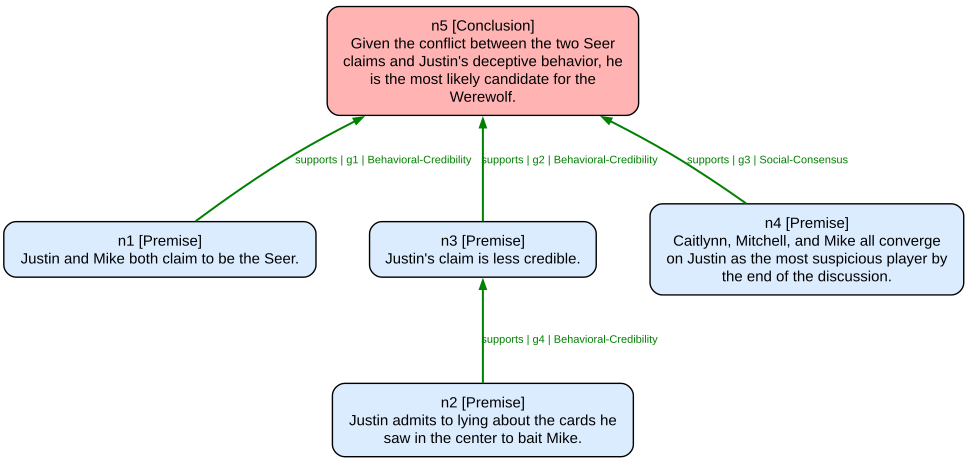

### Nodes

,id,argument_role,text
0,n1,Premise,Justin and Mike both claim to be the Seer.
1,n2,Premise,Justin admits to lying about the cards he saw ...
2,n3,Premise,Justin's claim is less credible.
3,n4,Premise,"Caitlynn, Mitchell, and Mike all converge on J..."
4,n5,Conclusion,Given the conflict between the two Seer claims...


### Edges

,source,target,relation,inference_group
0,n1,n5,supports,g1
1,n3,n5,supports,g2
2,n4,n5,supports,g3
3,n2,n3,supports,g4


### Inference groups

,inference_group,sources,target,relation,reasoning_type
0,g1,[n1],n5,supports,Behavioral-Credibility
1,g2,[n3],n5,supports,Behavioral-Credibility
2,g3,[n4],n5,supports,Social-Consensus
3,g4,[n2],n3,supports,Behavioral-Credibility


In [22]:
def show_validation_item(sample_df, validation_id):
    matches = sample_df[
        sample_df["validation_id"] == validation_id
    ]

    if len(matches) == 0:
        raise ValueError(
            f"No item found with validation_id={validation_id}"
        )

    row = matches.iloc[0]
    obj = row["raw_obj"]

    display(Markdown(f"# Validation item {validation_id}"))

    metadata_md = f"""
**Sample type:** {row['sample_type']}  
**Row index:** {row['row_index']}  
**Game ID:** {row['game_id']}  
**Run label:** {row['run_label']}  
**Chosen vote:** {row['chosen_vote']}  
**Vote correct:** {row['vote_correct']}  
**Nodes:** {row['n_nodes']}  
**Edges:** {row['n_edges']}  
**Inference groups:** {row['n_inference_groups']}  
**Lossless repairs:** {row['repair_types']}  
**Raw graph differs:** {row['raw_graph_differs']}  
**Raw schema issues:** {row['raw_schema_issues']}  
**Normalized schema issues:** {row['schema_issues']}  
"""
    display(Markdown(metadata_md))

    display(Markdown("## Justification"))
    display(Markdown(f"> {row['justification']}"))

    display(Markdown("## Normalized analysis graph"))
    draw_argument_graph_boxes(
        obj,
        graph_key="graph",
        text_width=42,
        figsize=None,
    )

    nodes_df, edges_df, groups_df = graph_to_tables(obj, graph_key="graph")

    display(Markdown("### Nodes"))
    display(nodes_df)
    display(Markdown("### Edges"))
    display(edges_df)
    display(Markdown("### Inference groups"))
    display(groups_df)

    repairs = obj.get("repairs", [])
    if repairs:
        display(Markdown("## Repair audit trail"))
        display(pd.DataFrame(repairs))

    if row["raw_graph_differs"]:
        display(Markdown("## Raw graph before normalization"))
        draw_argument_graph_boxes(
            obj,
            graph_key="raw_graph",
            text_width=42,
            figsize=None,
        )
        raw_nodes_df, raw_edges_df, raw_groups_df = graph_to_tables(
            obj,
            graph_key="raw_graph",
        )
        display(Markdown("### Raw nodes"))
        display(raw_nodes_df)
        display(Markdown("### Raw edges"))
        display(raw_edges_df)
        display(Markdown("### Raw inference groups"))
        display(raw_groups_df)


show_validation_item(sample_df, validation_id=1)


In [23]:
# Render either the review sample or every graph in the loaded run.
rows_to_render = df if RENDER_ALL_GRAPHS else sample_df

rendered_paths_by_record_id = {}
raw_rendered_paths_by_record_id = {}

for _, row in rows_to_render.iterrows():
    obj = row["raw_obj"]
    record_id = int(row["record_id"])
    row_index = row["row_index"]
    run_slug = re.sub(
        r"[^A-Za-z0-9._-]+",
        "_",
        str(row["run_label"]),
    ).strip("._-")

    image_path = (
        IMAGE_DIR
        / f"{run_slug}_record_{record_id:03d}_row_{row_index}.svg"
    )

    rendered_path = draw_argument_graph_boxes(
        obj,
        graph_key="graph",
        text_width=42,
        node_font_size=15,
        edge_font_size=11,
        save_path=image_path,
        show=False,
    )

    rendered_paths_by_record_id[record_id] = str(rendered_path)

    if row["raw_graph_differs"]:
        raw_image_path = (
            RAW_IMAGE_DIR
            / f"{run_slug}_record_{record_id:03d}_row_{row_index}_raw.svg"
        )
        raw_rendered_path = draw_argument_graph_boxes(
            obj,
            graph_key="raw_graph",
            text_width=42,
            node_font_size=15,
            edge_font_size=11,
            save_path=raw_image_path,
            show=False,
        )
        raw_rendered_paths_by_record_id[record_id] = str(raw_rendered_path)

sample_df = sample_df.copy()
sample_df["graph_image_path"] = sample_df["record_id"].map(
    rendered_paths_by_record_id
)
sample_df["raw_graph_image_path"] = sample_df["record_id"].map(
    raw_rendered_paths_by_record_id
)

missing_images = sample_df["graph_image_path"].isna().sum()
if missing_images:
    raise RuntimeError(
        f"{missing_images} review item(s) have no rendered graph image."
    )

print(
    f"Saved {len(rendered_paths_by_record_id)} normalized graph image(s) "
    f"to: {IMAGE_DIR}"
)
print(
    f"Saved {len(raw_rendered_paths_by_record_id)} raw comparison image(s) "
    f"to: {RAW_IMAGE_DIR}"
)
display(
    sample_df[
        [
            "validation_id",
            "run_label",
            "row_index",
            "repair_types",
            "graph_image_path",
            "raw_graph_image_path",
        ]
    ].head()
)


Saved 50 normalized graph image(s) to: C:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\unsloth_gemma-4-31B-it-unsloth-bnb-4bit\base\voting\prompt_v4\justification_analysis\three_call_deepseek\manual_review\mixed_n50_seed42\graph_images
Saved 0 raw comparison image(s) to: C:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\unsloth_gemma-4-31B-it-unsloth-bnb-4bit\base\voting\prompt_v4\justification_analysis\three_call_deepseek\manual_review\mixed_n50_seed42\raw_graph_images


,validation_id,run_label,row_index,repair_types,graph_image_path,raw_graph_image_path
0,1,run_2,310,[],C:\Users\annab\Documents\GitHub\masters_thesis...,NaN
1,2,run_3,454,[],C:\Users\annab\Documents\GitHub\masters_thesis...,NaN
2,3,greedy_t0,636,[],C:\Users\annab\Documents\GitHub\masters_thesis...,NaN
3,4,greedy_t0,757,[],C:\Users\annab\Documents\GitHub\masters_thesis...,NaN
4,5,run_2,251,[],C:\Users\annab\Documents\GitHub\masters_thesis...,NaN


### Build annotation app

In [24]:
from pathlib import Path
import json
import pandas as pd
import numpy as np

ANNOTATION_CSV_PATH = OUTPUT_DIR / "manual_graph_validation_live.csv"
ANNOTATION_APP_PATH = OUTPUT_DIR / "annotation_app.html"

SCORE_COLUMNS = [
    "component_segmentation",
    "conclusion_identification",
    "counter_arguments",
    "linked_independent_inferences",
    "completeness",
    "fidelity",
    "reasoning_type_correct",
]

ERROR_FLAG_COLUMNS = [
    "hallucinated_content",
    "missing_important_content",
    "overcompressed_nodes",
    "overfragmented_nodes",
    "wrong_edge_relation",
    "wrong_edge_target",
    "wrong_inference_group",
    "wrong_conclusion",
    "wrong_reasoning_type",
    "schema_error",
    "incorrect_repair",
]

METADATA_COLUMNS = [
    "validation_id",
    "sample_type",
    "record_id",
    "scope_name",
    "row_index",
    "game_id",
    "run_label",
    "chosen_vote",
    "vote_correct",
    "n_nodes",
    "n_edges",
    "n_inference_groups",
    "has_attack",
    "n_linked_inference_groups",
    "n_targets_with_multiple_inferences",
    "n_repairs",
    "repair_types",
    "raw_graph_differs",
    "n_raw_schema_issues",
    "n_schema_issues",
]


In [25]:
def make_empty_annotation_csv(sample_df, output_path):
    base_cols = [
        column
        for column in METADATA_COLUMNS
        if column in sample_df.columns
    ]
    annotation_df = sample_df[base_cols].copy()

    for column in SCORE_COLUMNS:
        annotation_df[column] = ""

    annotation_df["usable_for_analysis"] = ""

    for column in ERROR_FLAG_COLUMNS:
        annotation_df[column] = ""

    annotation_df["comments"] = ""
    annotation_df.to_csv(output_path, index=False)
    return annotation_df


if ANNOTATION_CSV_PATH.exists():
    annotations_df = pd.read_csv(ANNOTATION_CSV_PATH)

    required_columns = (
        SCORE_COLUMNS
        + ["usable_for_analysis"]
        + ERROR_FLAG_COLUMNS
        + ["comments"]
    )
    missing_columns = [
        column
        for column in required_columns
        if column not in annotations_df.columns
    ]

    if missing_columns:
        print(
            "Existing annotation CSV uses an older schema; "
            f"adding columns: {missing_columns}"
        )
        for column in missing_columns:
            annotations_df[column] = ""
        annotations_df.to_csv(ANNOTATION_CSV_PATH, index=False)
    else:
        print(
            f"Annotation CSV already exists, keeping it: "
            f"{ANNOTATION_CSV_PATH}"
        )
else:
    annotations_df = make_empty_annotation_csv(
        sample_df,
        ANNOTATION_CSV_PATH,
    )
    print(f"Created annotation CSV: {ANNOTATION_CSV_PATH}")

display(annotations_df.head())


Created annotation CSV: C:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\unsloth_gemma-4-31B-it-unsloth-bnb-4bit\base\voting\prompt_v4\justification_analysis\three_call_deepseek\manual_review\mixed_n50_seed42\manual_graph_validation_live.csv


,validation_id,sample_type,record_id,scope_name,row_index,game_id,run_label,chosen_vote,vote_correct,n_nodes,...,overcompressed_nodes,overfragmented_nodes,wrong_edge_relation,wrong_edge_target,wrong_inference_group,wrong_conclusion,wrong_reasoning_type,schema_error,incorrect_repair,comments
0,1,pilot,13,mixed_n50_seed42,310,Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF#39##Apri...,run_2,Justin,True,5,...,,,,,,,,,,
1,2,pilot,39,mixed_n50_seed42,454,Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF##Retro#3...,run_3,No Werewolf,True,5,...,,,,,,,,,,
2,3,pilot,30,mixed_n50_seed42,636,Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF##Retro#2...,greedy_t0,Mitchell,False,7,...,,,,,,,,,,
3,4,pilot,45,mixed_n50_seed42,757,Youtube / Way#Way#Back##ONE#NIGHT#ULTIMATE#WER...,greedy_t0,James,False,8,...,,,,,,,,,,
4,5,pilot,17,mixed_n50_seed42,251,Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF##Retro#2...,run_2,Justin,True,5,...,,,,,,,,,,


In [26]:
def json_safe(value):
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, np.bool_):
        return bool(value)
    if value is None:
        return None
    if isinstance(value, (list, dict, str, int, float, bool)):
        return value
    if pd.isna(value):
        return None
    return value


def make_relative_image_path(path, base_dir):
    if path is None or (isinstance(path, float) and pd.isna(path)):
        return None

    path = Path(path).resolve()
    base_dir = Path(base_dir).resolve()

    try:
        return path.relative_to(base_dir).as_posix()
    except ValueError:
        return path.as_uri()


def build_annotation_items(sample_df, output_dir):
    items = []

    for _, row in sample_df.iterrows():
        items.append({
            "validation_id": json_safe(row["validation_id"]),
            "sample_type": json_safe(row.get("sample_type", "")),
            "row_index": json_safe(row.get("row_index", "")),
            "game_id": json_safe(row.get("game_id", "")),
            "run_label": json_safe(row.get("run_label", "")),
            "chosen_vote": json_safe(row.get("chosen_vote", "")),
            "vote_correct": json_safe(row.get("vote_correct", "")),
            "n_nodes": json_safe(row.get("n_nodes", "")),
            "n_edges": json_safe(row.get("n_edges", "")),
            "n_inference_groups": json_safe(
                row.get("n_inference_groups", "")
            ),
            "n_repairs": json_safe(row.get("n_repairs", 0)),
            "repair_types": json_safe(row.get("repair_types", [])),
            "repairs": json_safe(row.get("repairs", [])),
            "raw_graph_differs": json_safe(
                row.get("raw_graph_differs", False)
            ),
            "raw_schema_issues": json_safe(
                row.get("raw_schema_issues", [])
            ),
            "schema_issues": json_safe(row.get("schema_issues", [])),
            "justification": json_safe(row.get("justification", "")),
            "graph_image_path": make_relative_image_path(
                row["graph_image_path"],
                output_dir,
            ),
            "raw_graph_image_path": make_relative_image_path(
                row.get("raw_graph_image_path"),
                output_dir,
            ),
        })

    return items


annotation_items = build_annotation_items(sample_df, OUTPUT_DIR)

print(f"Prepared {len(annotation_items)} annotation items.")
print(annotation_items[0])


Prepared 50 annotation items.
{'validation_id': 1, 'sample_type': 'pilot', 'row_index': 310, 'game_id': 'Youtube / ONE#NIGHT#ULTIMATE#WEREWOLF#39##April#21st#2018 / Game3', 'run_label': 'run_2', 'chosen_vote': 'Justin', 'vote_correct': True, 'n_nodes': 5, 'n_edges': 4, 'n_inference_groups': 4, 'n_repairs': 0, 'repair_types': [], 'repairs': [], 'raw_graph_differs': False, 'raw_schema_issues': [], 'schema_issues': [], 'justification': "Justin and Mike both claim to be the Seer, but Justin admits to lying about the cards he saw in the center to bait Mike, which makes his claim less credible. Caitlynn, Mitchell, and Mike all converge on Justin as the most suspicious player by the end of the discussion. Given the conflict between the two Seer claims and Justin's deceptive behavior, he is the most likely candidate for the Werewolf.", 'graph_image_path': 'graph_images/run_2_record_013_row_310.svg', 'raw_graph_image_path': None}


In [27]:
annotation_html = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>Argument Graph Annotation App</title>
    <style>
        body {{
            margin: 0;
            font-family: Arial, sans-serif;
            background: #f5f5f5;
            color: #222;
        }}

        header {{
            position: sticky;
            top: 0;
            z-index: 10;
            background: #222;
            color: white;
            padding: 10px 18px;
            display: flex;
            align-items: center;
            gap: 12px;
        }}

        header button {{
            padding: 8px 12px;
            border: none;
            border-radius: 6px;
            cursor: pointer;
            font-weight: bold;
        }}

        header input {{
            width: 70px;
            padding: 6px;
        }}

        #status {{
            margin-left: auto;
            font-weight: bold;
        }}

        main {{
            display: grid;
            grid-template-columns: 1fr 380px;
            gap: 16px;
            padding: 16px;
        }}

        .left-panel, .right-panel {{
            background: white;
            border-radius: 10px;
            padding: 16px;
            box-shadow: 0 1px 5px rgba(0,0,0,0.12);
        }}

        .metadata {{
            font-size: 14px;
            color: #444;
            margin-bottom: 12px;
            line-height: 1.4;
        }}

        .justification {{
            background: #f7f7f7;
            border-left: 4px solid #777;
            padding: 12px;
            white-space: pre-wrap;
            line-height: 1.45;
            margin-bottom: 16px;
        }}

        .graph-container {{
            width: 100%;
            overflow: auto;
            border: 1px solid #ddd;
            border-radius: 8px;
            background: white;
        }}

        .graph-container img {{
            max-width: none;
            width: 100%;
            min-width: 900px;
            display: block;
        }}

        .repair-box {{
            background: #fff8df;
            border-left: 4px solid #d9a400;
            padding: 10px;
            margin-bottom: 16px;
            white-space: pre-wrap;
            font-family: monospace;
            font-size: 12px;
        }}

        #rawGraphSection {{
            display: none;
            margin-top: 20px;
        }}

        .section-title {{
            margin-top: 16px;
            margin-bottom: 8px;
            font-size: 16px;
            font-weight: bold;
        }}

        .score-row {{
            display: grid;
            grid-template-columns: 1fr auto;
            gap: 8px;
            align-items: center;
            margin-bottom: 8px;
            padding-bottom: 8px;
            border-bottom: 1px solid #eee;
        }}

        .score-buttons {{
            display: flex;
            gap: 4px;
        }}

        .score-buttons button,
        .yesno-buttons button {{
            border: 1px solid #bbb;
            background: white;
            border-radius: 5px;
            padding: 5px 8px;
            cursor: pointer;
        }}

        .score-buttons button.selected,
        .yesno-buttons button.selected {{
            background: #222;
            color: white;
            border-color: #222;
        }}

        .flag-row {{
            display: flex;
            align-items: center;
            gap: 8px;
            margin-bottom: 6px;
            font-size: 14px;
        }}

        textarea {{
            width: 100%;
            min-height: 90px;
            resize: vertical;
            font-family: Arial, sans-serif;
            padding: 8px;
            box-sizing: border-box;
        }}

        .save-button {{
            width: 100%;
            margin-top: 14px;
            padding: 12px;
            border: none;
            border-radius: 8px;
            background: #0b6bcb;
            color: white;
            font-size: 16px;
            font-weight: bold;
            cursor: pointer;
        }}

        .save-button:hover {{
            background: #084f96;
        }}

        .small-note {{
            color: #666;
            font-size: 13px;
            margin-top: 8px;
        }}
    </style>
</head>

<body>
<header>
    <button onclick="prevItem()">← Previous</button>
    <button onclick="nextItem()">Next →</button>
    <span>Go to:</span>
    <input id="jumpInput" type="number" min="1">
    <button onclick="jumpToItem()">Go</button>
    <span id="progress"></span>
    <span id="status">Not saved yet</span>
</header>

<main>
    <div class="left-panel">
        <h2 id="title"></h2>
        <div id="metadata" class="metadata"></div>

        <h3>Justification</h3>
        <div id="justification" class="justification"></div>

        <h3>Lossless repair log</h3>
        <div id="repairs" class="repair-box"></div>

        <h3>Normalized analysis graph</h3>
        <div class="graph-container">
            <img id="graphImage" src="">
        </div>

        <div id="rawGraphSection">
            <h3>Raw graph before normalization</h3>
            <div class="small-note">Use this comparison to verify that repairs did not change argumentative meaning.</div>
            <div class="graph-container">
                <img id="rawGraphImage" src="">
            </div>
        </div>
    </div>

    <div class="right-panel">
        <h2>Manual annotation</h2>

        <div class="small-note">
            Scores: 1 = incorrect, 2 = partial, 3 = correct.
        </div>

        <div class="section-title">Prompt-compliance scores</div>
        <div id="scoreFields"></div>

        <div class="section-title">Usable for analysis</div>
        <div class="yesno-buttons">
            <button id="usable_yes" onclick="setUsable('yes')">Yes</button>
            <button id="usable_no" onclick="setUsable('no')">No</button>
        </div>

        <div class="section-title">Error flags</div>
        <div id="flagFields"></div>

        <div class="section-title">Comments</div>
        <textarea id="comments" placeholder="Write notes here..."></textarea>

        <button class="save-button" onclick="saveAnnotation()">Save annotation</button>

        <div class="small-note">
            Tip: saving also happens when you move to next/previous.
        </div>
    </div>
</main>

<script>
const ITEMS = {json.dumps(annotation_items, ensure_ascii=False)};
const SCORE_COLUMNS = {json.dumps(SCORE_COLUMNS)};
const ERROR_FLAG_COLUMNS = {json.dumps(ERROR_FLAG_COLUMNS)};

let currentIndex = 0;
let annotations = {{}};

function emptyAnnotation() {{
    let ann = {{}};

    for (const col of SCORE_COLUMNS) {{
        ann[col] = "";
    }}

    ann["usable_for_analysis"] = "";

    for (const col of ERROR_FLAG_COLUMNS) {{
        ann[col] = 0;
    }}

    ann["comments"] = "";

    return ann;
}}

function getCurrentItem() {{
    return ITEMS[currentIndex];
}}

function getCurrentAnnotation() {{
    const id = getCurrentItem().validation_id;
    if (!(id in annotations)) {{
        annotations[id] = emptyAnnotation();
    }}
    return annotations[id];
}}

function renderScoreFields() {{
    const container = document.getElementById("scoreFields");
    container.innerHTML = "";

    for (const col of SCORE_COLUMNS) {{
        const row = document.createElement("div");
        row.className = "score-row";

        const label = document.createElement("div");
        label.textContent = col;

        const buttons = document.createElement("div");
        buttons.className = "score-buttons";

        for (const value of [1, 2, 3]) {{
            const btn = document.createElement("button");
            btn.textContent = value;
            btn.id = `score_${{col}}_${{value}}`;
            btn.onclick = () => setScore(col, value);
            buttons.appendChild(btn);
        }}

        row.appendChild(label);
        row.appendChild(buttons);
        container.appendChild(row);
    }}
}}

function renderFlagFields() {{
    const container = document.getElementById("flagFields");
    container.innerHTML = "";

    for (const col of ERROR_FLAG_COLUMNS) {{
        const row = document.createElement("label");
        row.className = "flag-row";

        const checkbox = document.createElement("input");
        checkbox.type = "checkbox";
        checkbox.id = `flag_${{col}}`;
        checkbox.onchange = () => {{
            const ann = getCurrentAnnotation();
            ann[col] = checkbox.checked ? 1 : 0;
        }};

        const text = document.createElement("span");
        text.textContent = col;

        row.appendChild(checkbox);
        row.appendChild(text);
        container.appendChild(row);
    }}
}}

function renderItem() {{
    const item = getCurrentItem();
    const ann = getCurrentAnnotation();

    document.getElementById("title").textContent =
        `Validation item ${{item.validation_id}}`;

    document.getElementById("progress").textContent =
        `${{currentIndex + 1}} / ${{ITEMS.length}}`;

    document.getElementById("jumpInput").value = currentIndex + 1;

    document.getElementById("metadata").innerHTML = `
        <b>Sample type:</b> ${{item.sample_type}}<br>
        <b>Row index:</b> ${{item.row_index}}<br>
        <b>Game ID:</b> ${{item.game_id}}<br>
        <b>Run label:</b> ${{item.run_label}}<br>
        <b>Chosen vote:</b> ${{item.chosen_vote}}<br>
        <b>Vote correct:</b> ${{item.vote_correct}}<br>
        <b>Nodes:</b> ${{item.n_nodes}} |
        <b>Edges:</b> ${{item.n_edges}} |
        <b>Inference groups:</b> ${{item.n_inference_groups}}<br>
        <b>Lossless repairs:</b> ${{item.n_repairs}} (${{item.repair_types.join(", ") || "none"}})<br>
        <b>Raw graph differs:</b> ${{item.raw_graph_differs}}<br>
        <b>Raw schema issues:</b> ${{item.raw_schema_issues.join(", ") || "none"}}<br>
        <b>Normalized schema issues:</b> ${{item.schema_issues.join(", ") || "none"}}
    `;

    document.getElementById("justification").textContent = item.justification;
    document.getElementById("repairs").textContent = item.repairs.length
        ? JSON.stringify(item.repairs, null, 2)
        : "No repair was applied.";
    document.getElementById("graphImage").src = item.graph_image_path;

    const rawSection = document.getElementById("rawGraphSection");
    const rawImage = document.getElementById("rawGraphImage");
    if (item.raw_graph_image_path) {{
        rawSection.style.display = "block";
        rawImage.src = item.raw_graph_image_path;
    }} else {{
        rawSection.style.display = "none";
        rawImage.src = "";
    }}

    // Scores
    for (const col of SCORE_COLUMNS) {{
        for (const value of [1, 2, 3]) {{
            const btn = document.getElementById(`score_${{col}}_${{value}}`);
            if (btn) {{
                btn.classList.toggle("selected", String(ann[col]) === String(value));
            }}
        }}
    }}

    // Usable
    document.getElementById("usable_yes").classList.toggle(
        "selected",
        ann["usable_for_analysis"] === "yes"
    );

    document.getElementById("usable_no").classList.toggle(
        "selected",
        ann["usable_for_analysis"] === "no"
    );

    // Flags
    for (const col of ERROR_FLAG_COLUMNS) {{
        const checkbox = document.getElementById(`flag_${{col}}`);
        if (checkbox) {{
            checkbox.checked = Number(ann[col]) === 1;
        }}
    }}

    document.getElementById("comments").value = ann["comments"] || "";

    document.getElementById("status").textContent = "Loaded";
}}

function setScore(col, value) {{
    const ann = getCurrentAnnotation();
    ann[col] = value;
    renderItem();
}}

function setUsable(value) {{
    const ann = getCurrentAnnotation();
    ann["usable_for_analysis"] = value;
    renderItem();
}}

function collectCurrentForm() {{
    const ann = getCurrentAnnotation();
    ann["comments"] = document.getElementById("comments").value;

    for (const col of ERROR_FLAG_COLUMNS) {{
        const checkbox = document.getElementById(`flag_${{col}}`);
        ann[col] = checkbox && checkbox.checked ? 1 : 0;
    }}

    return ann;
}}

async function saveAnnotation() {{
    const item = getCurrentItem();
    const ann = collectCurrentForm();

    const payload = {{
        validation_id: item.validation_id,
        annotation: ann
    }};

    document.getElementById("status").textContent = "Saving...";

    try {{
        const response = await fetch("/save_annotation", {{
            method: "POST",
            headers: {{
                "Content-Type": "application/json"
            }},
            body: JSON.stringify(payload)
        }});

        if (!response.ok) {{
            throw new Error("Server returned " + response.status);
        }}

        document.getElementById("status").textContent = "Saved ✓";
    }} catch (error) {{
        console.error(error);
        document.getElementById("status").textContent = "Save failed!";
        alert("Save failed. Check the notebook server output.");
    }}
}}

async function prevItem() {{
    await saveAnnotation();
    if (currentIndex > 0) {{
        currentIndex -= 1;
        renderItem();
    }}
}}

async function nextItem() {{
    await saveAnnotation();
    if (currentIndex < ITEMS.length - 1) {{
        currentIndex += 1;
        renderItem();
    }}
}}

async function jumpToItem() {{
    await saveAnnotation();

    const value = Number(document.getElementById("jumpInput").value);

    if (value >= 1 && value <= ITEMS.length) {{
        currentIndex = value - 1;
        renderItem();
    }}
}}

document.addEventListener("keydown", async function(event) {{
    if (event.ctrlKey && event.key === "s") {{
        event.preventDefault();
        await saveAnnotation();
    }}

    if (event.altKey && event.key === "ArrowRight") {{
        event.preventDefault();
        await nextItem();
    }}

    if (event.altKey && event.key === "ArrowLeft") {{
        event.preventDefault();
        await prevItem();
    }}
}});

renderScoreFields();
renderFlagFields();
renderItem();
</script>
</body>
</html>
"""

ANNOTATION_APP_PATH.write_text(annotation_html, encoding="utf-8")

print(f"Saved annotation app to: {ANNOTATION_APP_PATH}")

Saved annotation app to: C:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\unsloth_gemma-4-31B-it-unsloth-bnb-4bit\base\voting\prompt_v4\justification_analysis\three_call_deepseek\manual_review\mixed_n50_seed42\annotation_app.html


In [ ]:
import json
import threading
import socket
import webbrowser
from http.server import SimpleHTTPRequestHandler, ThreadingHTTPServer
from urllib.parse import urlparse

SAVE_LOCK = threading.Lock()


def find_free_port(start=8000, end=8100):
    for port in range(start, end):
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            try:
                s.bind(("localhost", port))
                return port
            except OSError:
                continue
    raise RuntimeError("No free port found.")


def update_annotation_csv(validation_id, annotation):
    """
    Update one row of the annotation CSV.
    """
    validation_id = int(validation_id)

    with SAVE_LOCK:
        df_ann = pd.read_csv(ANNOTATION_CSV_PATH)

        if "validation_id" not in df_ann.columns:
            raise ValueError("annotation CSV has no validation_id column")

        mask = df_ann["validation_id"].astype(int) == validation_id

        if not mask.any():
            raise ValueError(f"validation_id not found in CSV: {validation_id}")

        for col, value in annotation.items():
            if col not in df_ann.columns:
                df_ann[col] = ""

            df_ann.loc[mask, col] = value

        df_ann.to_csv(ANNOTATION_CSV_PATH, index=False)


class AnnotationRequestHandler(SimpleHTTPRequestHandler):
    def do_POST(self):
        parsed = urlparse(self.path)

        if parsed.path != "/save_annotation":
            self.send_response(404)
            self.end_headers()
            self.wfile.write(b"Not found")
            return

        content_length = int(self.headers.get("Content-Length", 0))
        body = self.rfile.read(content_length)

        try:
            payload = json.loads(body.decode("utf-8"))
            validation_id = payload["validation_id"]
            annotation = payload["annotation"]

            update_annotation_csv(validation_id, annotation)

            response = {"status": "ok"}

            self.send_response(200)
            self.send_header("Content-Type", "application/json")
            self.end_headers()
            self.wfile.write(json.dumps(response).encode("utf-8"))

        except Exception as e:
            response = {"status": "error", "message": str(e)}

            self.send_response(500)
            self.send_header("Content-Type", "application/json")
            self.end_headers()
            self.wfile.write(json.dumps(response).encode("utf-8"))


PORT = find_free_port()

server = ThreadingHTTPServer(
    ("localhost", PORT),
    AnnotationRequestHandler
)

# Serve files from OUTPUT_DIR
server.directory = str(OUTPUT_DIR.resolve())

def run_server():
    import os
    old_cwd = os.getcwd()
    os.chdir(OUTPUT_DIR.resolve())
    try:
        server.serve_forever()
    finally:
        os.chdir(old_cwd)

thread = threading.Thread(target=run_server, daemon=True)
thread.start()

url = f"http://localhost:{PORT}/{ANNOTATION_APP_PATH.name}"

print(f"Annotation server running at:")
print(url)
print()
print(f"Annotations will be saved to:")
print(ANNOTATION_CSV_PATH)

webbrowser.open_new_tab(url)

Annotation server running at:
http://localhost:8000/annotation_app.html

Annotations will be saved to:
C:\Users\annab\Documents\GitHub\masters_thesis_sdg\analysis\unsloth_gemma-4-31B-it-unsloth-bnb-4bit\base\voting\prompt_v4\justification_analysis\three_call_deepseek\manual_review\mixed_n50_seed42\manual_graph_validation_live.csv


True

127.0.0.1 - - [15/Jul/2026 15:02:39] "GET /annotation_app.html HTTP/1.1" 200 -
127.0.0.1 - - [15/Jul/2026 15:02:39] "GET /graph_images/run_2_record_013_row_310.svg HTTP/1.1" 200 -
127.0.0.1 - - [15/Jul/2026 15:02:39] code 404, message File not found
127.0.0.1 - - [15/Jul/2026 15:02:39] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [15/Jul/2026 15:02:49] "GET /annotation_app.html HTTP/1.1" 304 -
127.0.0.1 - - [15/Jul/2026 15:02:49] "GET /graph_images/run_2_record_013_row_310.svg HTTP/1.1" 304 -
C:\Users\annab\AppData\Local\Temp\ipykernel_16472\3757496420.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_ann.loc[mask, col] = value
C:\Users\annab\AppData\Local\Temp\ipykernel_16472\3757496420.py:43: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version 

In [29]:
server.shutdown()
print("Annotation server stopped.")

Annotation server stopped.


In [ ]:
review = pd.read_csv(ANNOTATION_CSV_PATH)
display(review.head())
print("Annotated rows:", int(review["usable_for_analysis"].notna().sum()))
